### Требуемое железо  

Веса модели фиксированные `167 gb`.  
- OK: Помещается на 2 NVIDIA PRO 6000  

- OK: Помещается на 4 NVIDIA A100 + 100 гб памяти под KV-cache `GPU_MEMORY_UTILIZATION: "0.965"`, длинный контекст, и большее кол-во одновременных запросов.  

- BAD: Обычные игровые карты вроде RTX 4090 не объединяются по NVLink/XGMI должным образом для эффективного Tensor Parallel такого уровня, и их памяти (24GB) может не хватить на огромный KV-кэш при высоком параллелизме (max-num-seqs).

KV-cache (Key-Value Cache): Это динамическая память, куда vLLM сохраняет математические «слепки» всех слов из вашего диалога. Чем длиннее история чата и чем больше контекстное окно, тем гигантских размеров становится этот кэш.

---

Текущие конфигурации serverflow жестко завязаны на работу **4 GPU**: (`TP_SIZE: "4"`, `CUDA_VISIBLE_DEVICES: "0,1,2,3"`)

- **RAM (ОЗУ хоста):** Минимум **256 GB** (в правом контейнере под общую память `/dev/shm` выделяется 64 GB)

- **Диск:** NVMe SSD от **500 GB** (для кэша vLLM и самой модели).

### Как их запустить

Поскольку оба контейнера используют режим `network_mode: host` и претендуют на одни и те же GPU (0,1,2,3) и один порт (8000), **одновременно на одной машине их запустить нельзя** — возникнет конфликт портов и аллокации памяти видеокарт. Их нужно запускать по очереди для тестов.

1. Проверить на сервере установленный **docker-compose** и настроенный **NVIDIA Container Toolkit**.

2. Подготовка папок. Модель должна лежать на вашем сервере по пути, указанному в `volumes`. Создайте эти директории:

- mkdir -p /home/user/models/DeepSeek-Flash
- mkdir -p /home/user/vllm-cache
- mkdir -p /home/user/vllm-tmp

_(Поместите файлы весов модели DeepSeek в папку `/home/user/models/DeepSeek-Flash`)_

3. Запуск конфигурации. Сохраните код нужного контейнера в файл `docker-compose.yml` в отдельную папку и выполните команду для запуска в фоновом режиме:

- docker compose up -d

4. Проверка логов. Так как модели огромные, они могут загружаться в память несколько минут. Следить за процессом можно через команду:

- docker compose logs -f vllm

Как только в логах появится строка `Application startup complete. Uvicorn running on http://0.0.0`, модель готова принимать запросы через стандартный OpenAI-совместимый API.

---

#### Флаги командной строки 

`--tool-call-parser=deepseek_v4` (Парсеры инструментов / Tool Call Parsers) — это специальные программные модули, которые переводят скрытые рассуждения нейросети в структурированный формат (обычно JSON), когда модель решает вызвать внешнюю функцию (например, запустить калькулятор, сделать запрос в базу данных или вызвать API погоды).  

>Когда вы просите модель: «Узнай погоду в Москве и пришли ответ», модель генерирует текст. Парсер подхватывает этот текст, вычленяет из него команду типа {"name": "get_weather", "arguments": {"location": "Moscow"}} и передает ее вашей системе.  

`--reasoning-parser=deepseek_v4` («внутренний монолог» / Chain of Thought) — модель внутри себя пишет черновик кода, затем сама же «читает» его глазами и симулирует работу компилятора: «Так, если я передам сюда массив, то на шаге 5 возникнет утечка памяти. Нужно переписать». Только после этих виртуальных проверок она выдает итоговый вариант.  

>Скорость и качество написания кода у таких моделей в разы выше, но они всё равно физически не запускают двоичный файл на процессоре.  

### Что такое режим FP8?

**FP8 (Floating Point 8-bit)** — это ультрасовременный формат представления чисел с плавающей запятой, использующий всего **8 бит (1 байт)** на один параметр. Для сравнения, классическое обучение и запуск нейросетей раньше происходили в форматах FP32 (4 байта) или FP16/BF16 (2 байта).

Переход на FP8 — это главный технологический тренд последних лет в сфере LLM. Он дает критически важные преимущества:

- **Экономия памяти ровно в 2 раза** по сравнению с BF16. Веса модели и данные контекста (KV-кэш) занимают вдвое меньше места в видеопамяти.  

- **Двукратное ускорение генерации.** Современные видеокарты (особенно поколения NVIDIA Hopper H100/H200, в которых появились выделенные трансформерные движки — Transformer Engine) умеют проводить вычисления над FP8 числами на аппаратном уровне с колоссальной скоростью.  

- **Почти без потери качества.** Математические алгоритмы сжатия в FP8 оптимизированы так, что точность ответов огромных моделей падает всего на доли процента, что незаметно на практике.

#### Замеры [LLM] vs [patch r27] vs [patch r27 DSPARK]

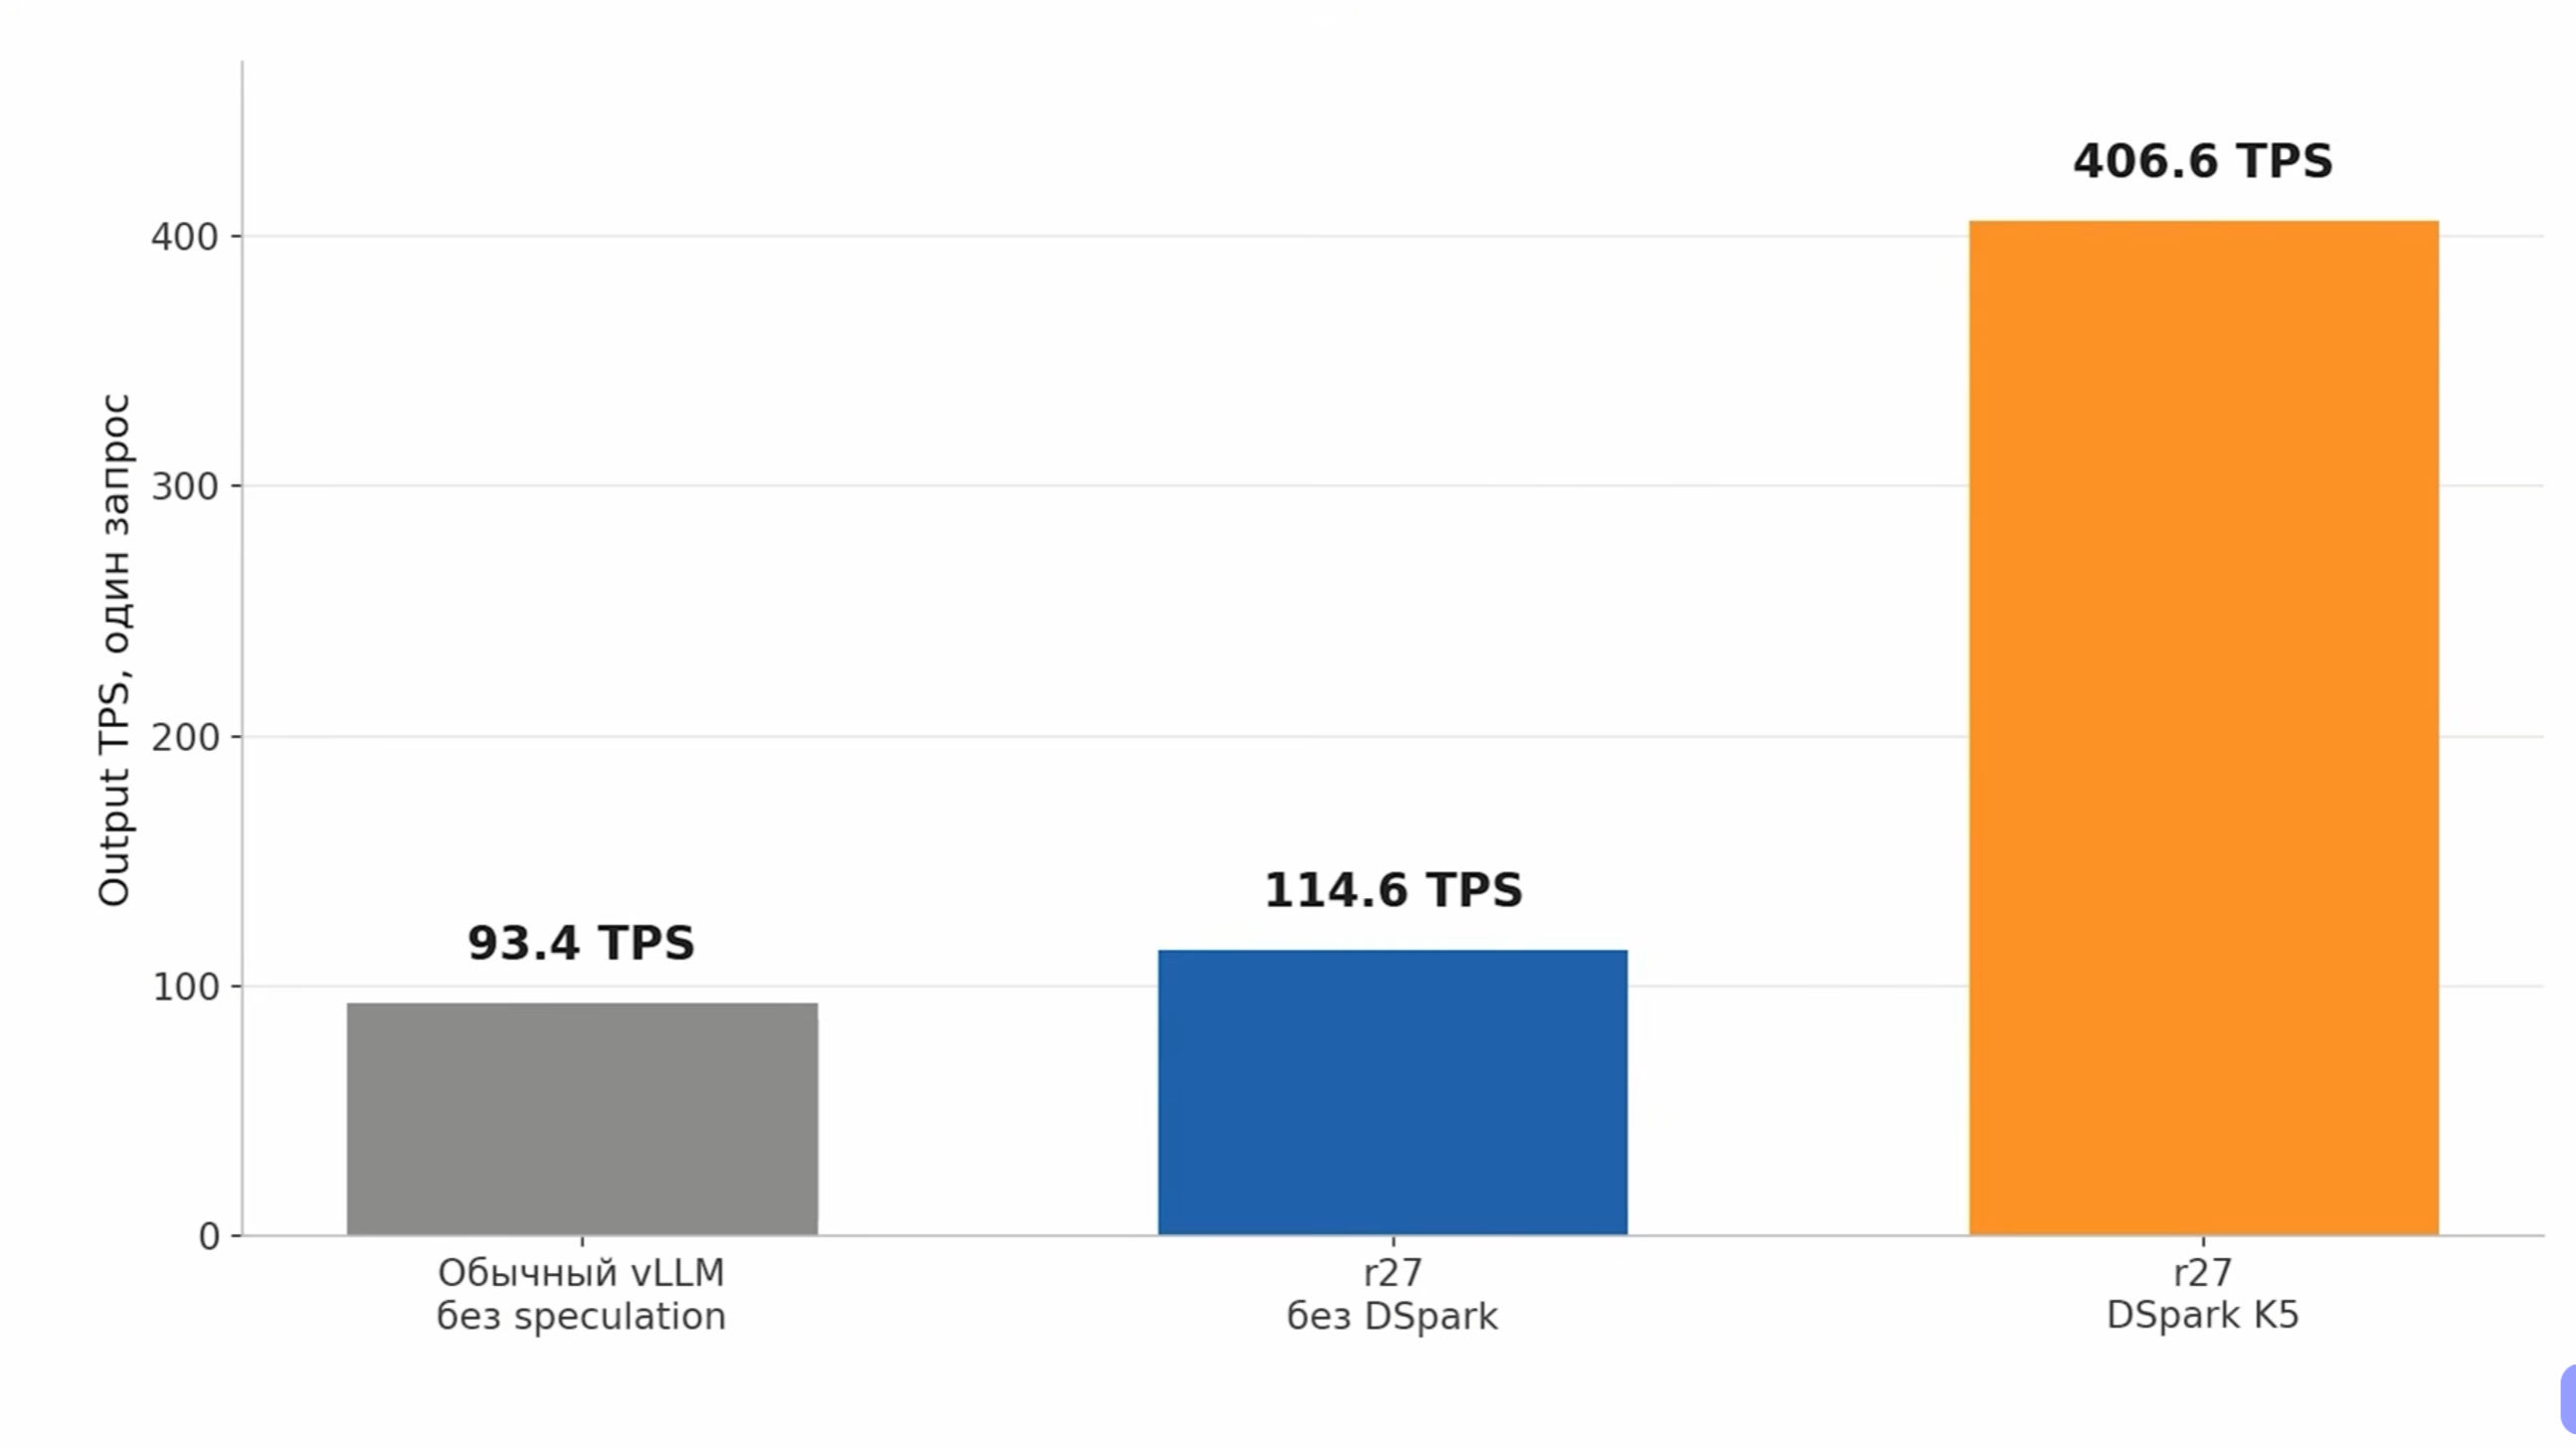

- Патч r27 дал прирост 23%  
- Патч r27 + DSpark дал прирост в 4.5 раза!

#### Как сервер справляется с параллельными запросами

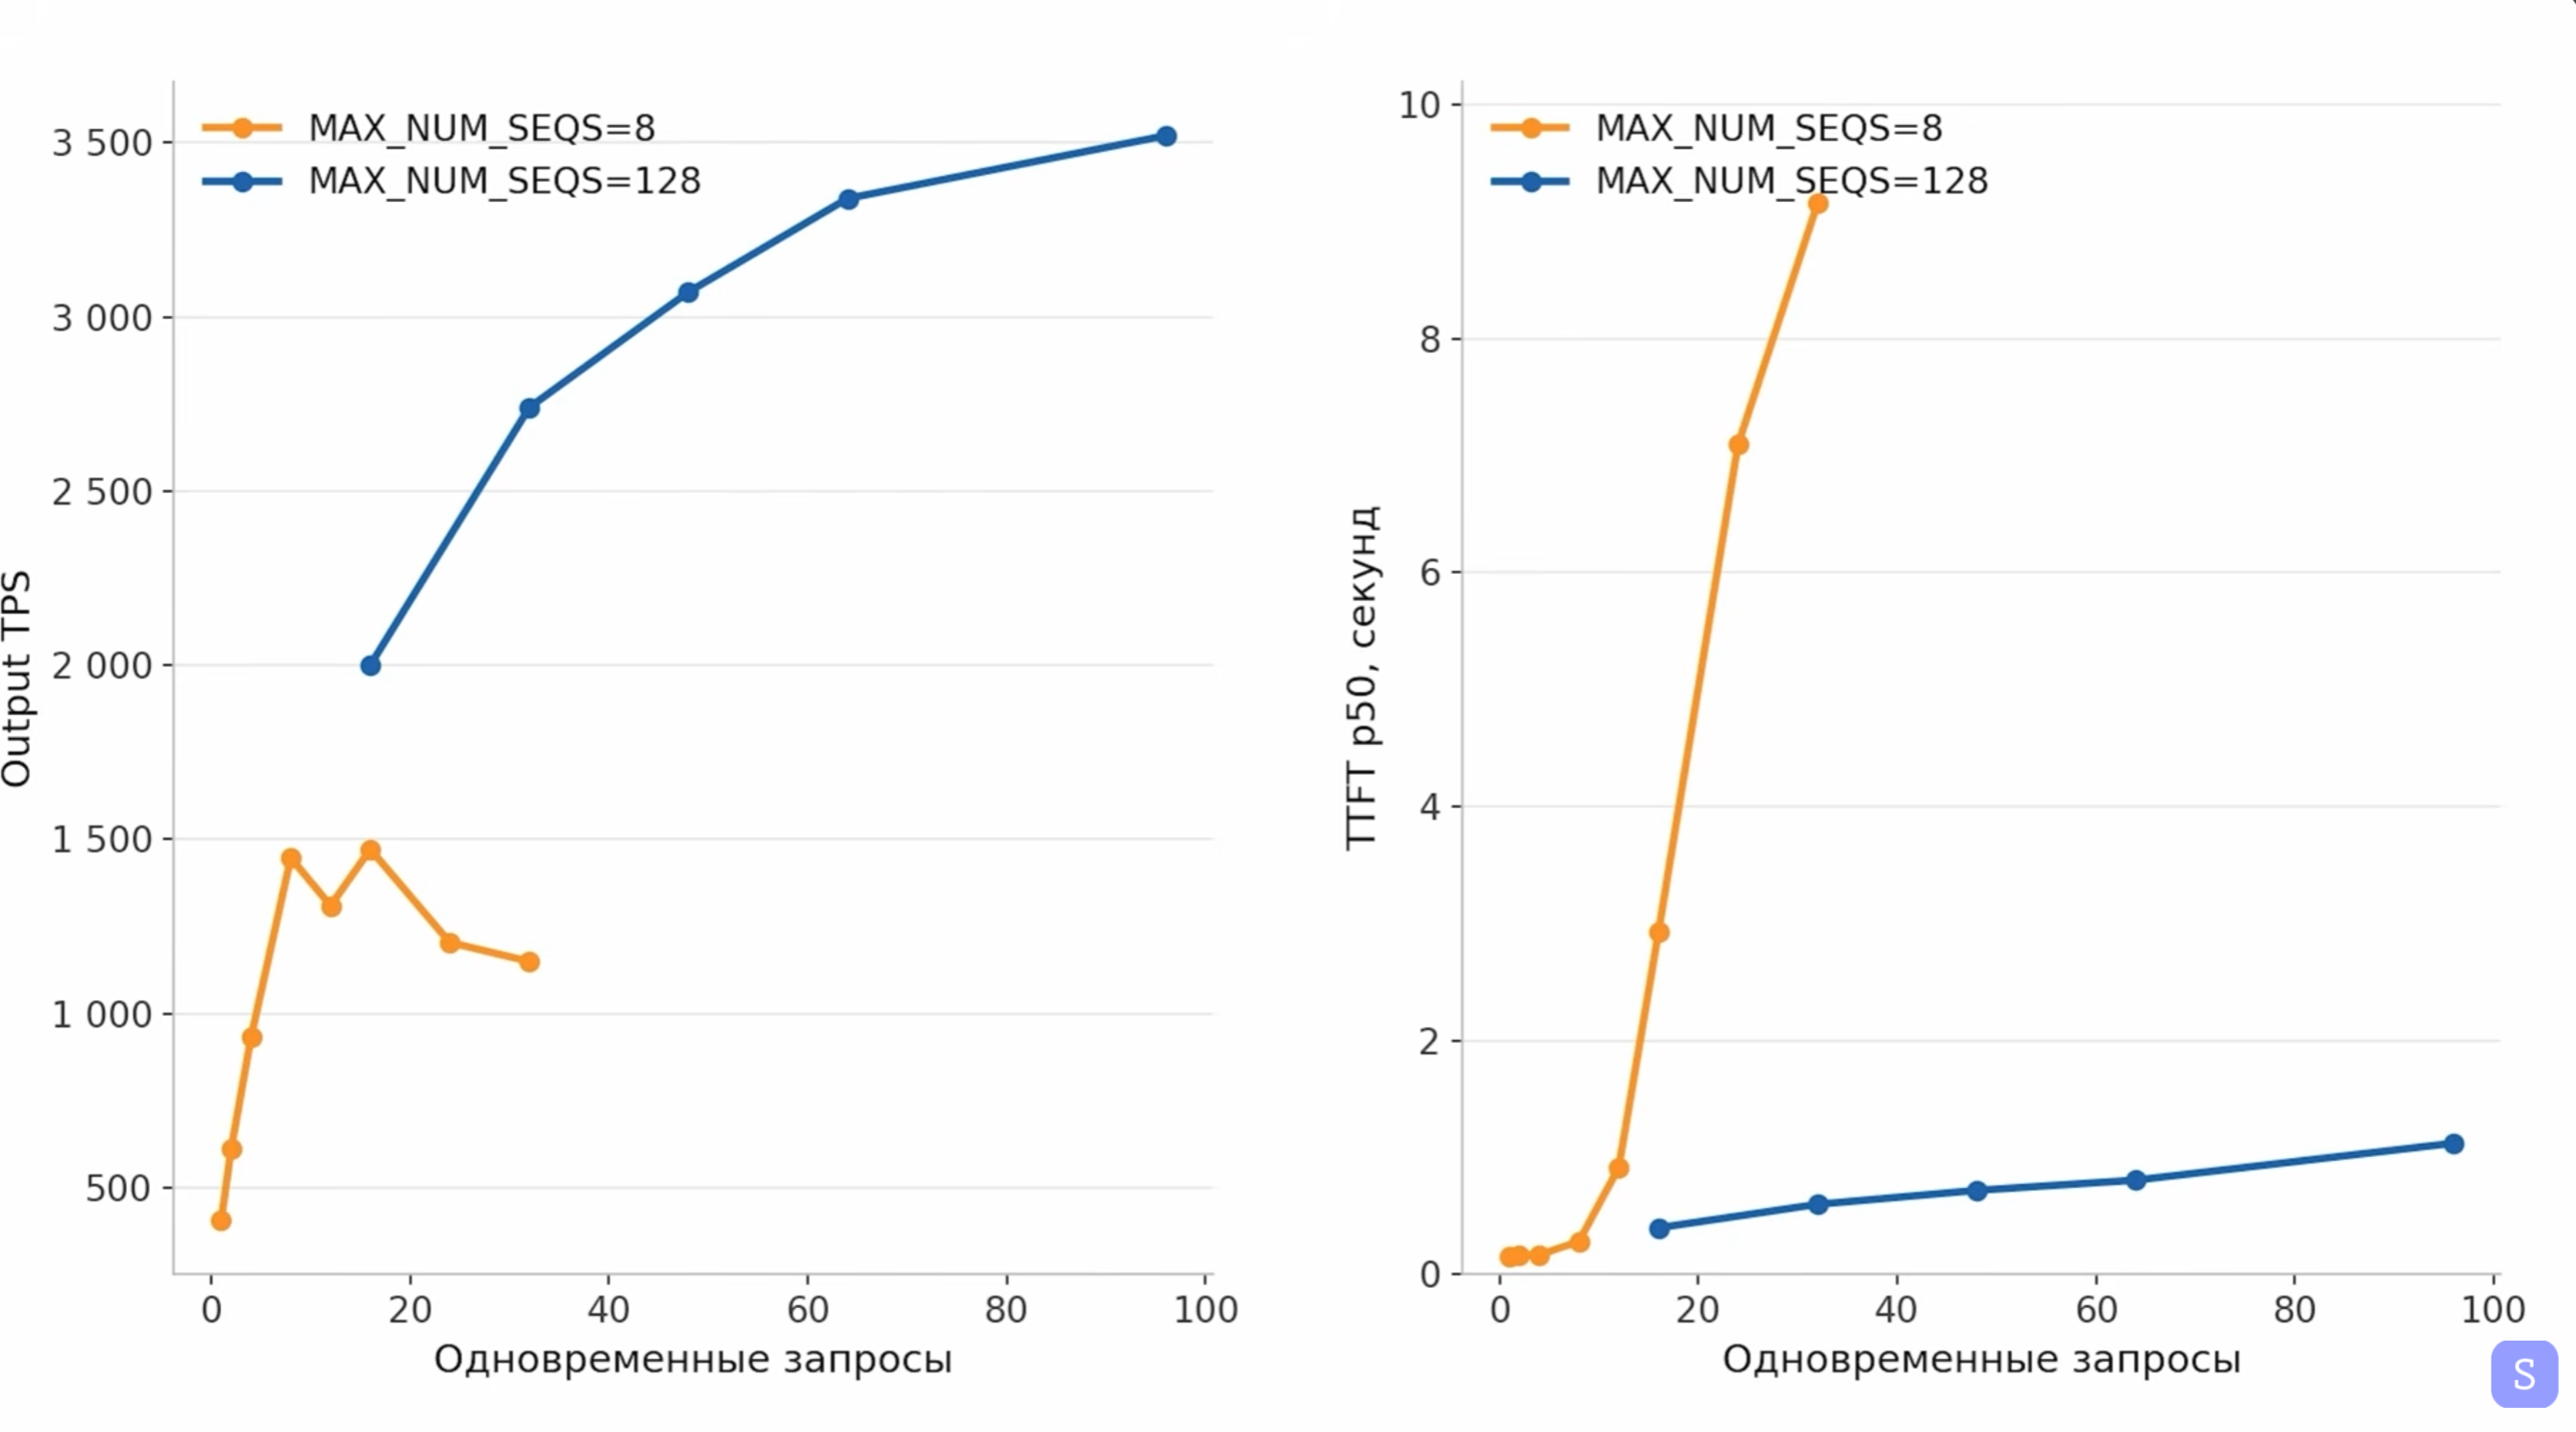

- 3500 токенов в секунду на 100 запросов = 35 токенов в секунду на 1 запрос  
- медианное время ожидания модели около 1 секунды

#### Тест модели на больших входных промптах  

Верхний график `TTFT (Time To First Token)`  
Сколько времени сервер обрабатывает промпт до первого токена на выходе. В этот момент видеокарты заняты фазой Prefill — они «вчитываются» в текст, строят карту связей и забивают KV-кэш в видеопамяти.  

Нижний график `Decode TPS (Tokens Per Second)`  
Скорость, с которой модель «выплевывает» слова на экран, когда фаза чтения уже завершена и начался сам ответ (фаза Decode). График построен для одного потока (одного пользователя).

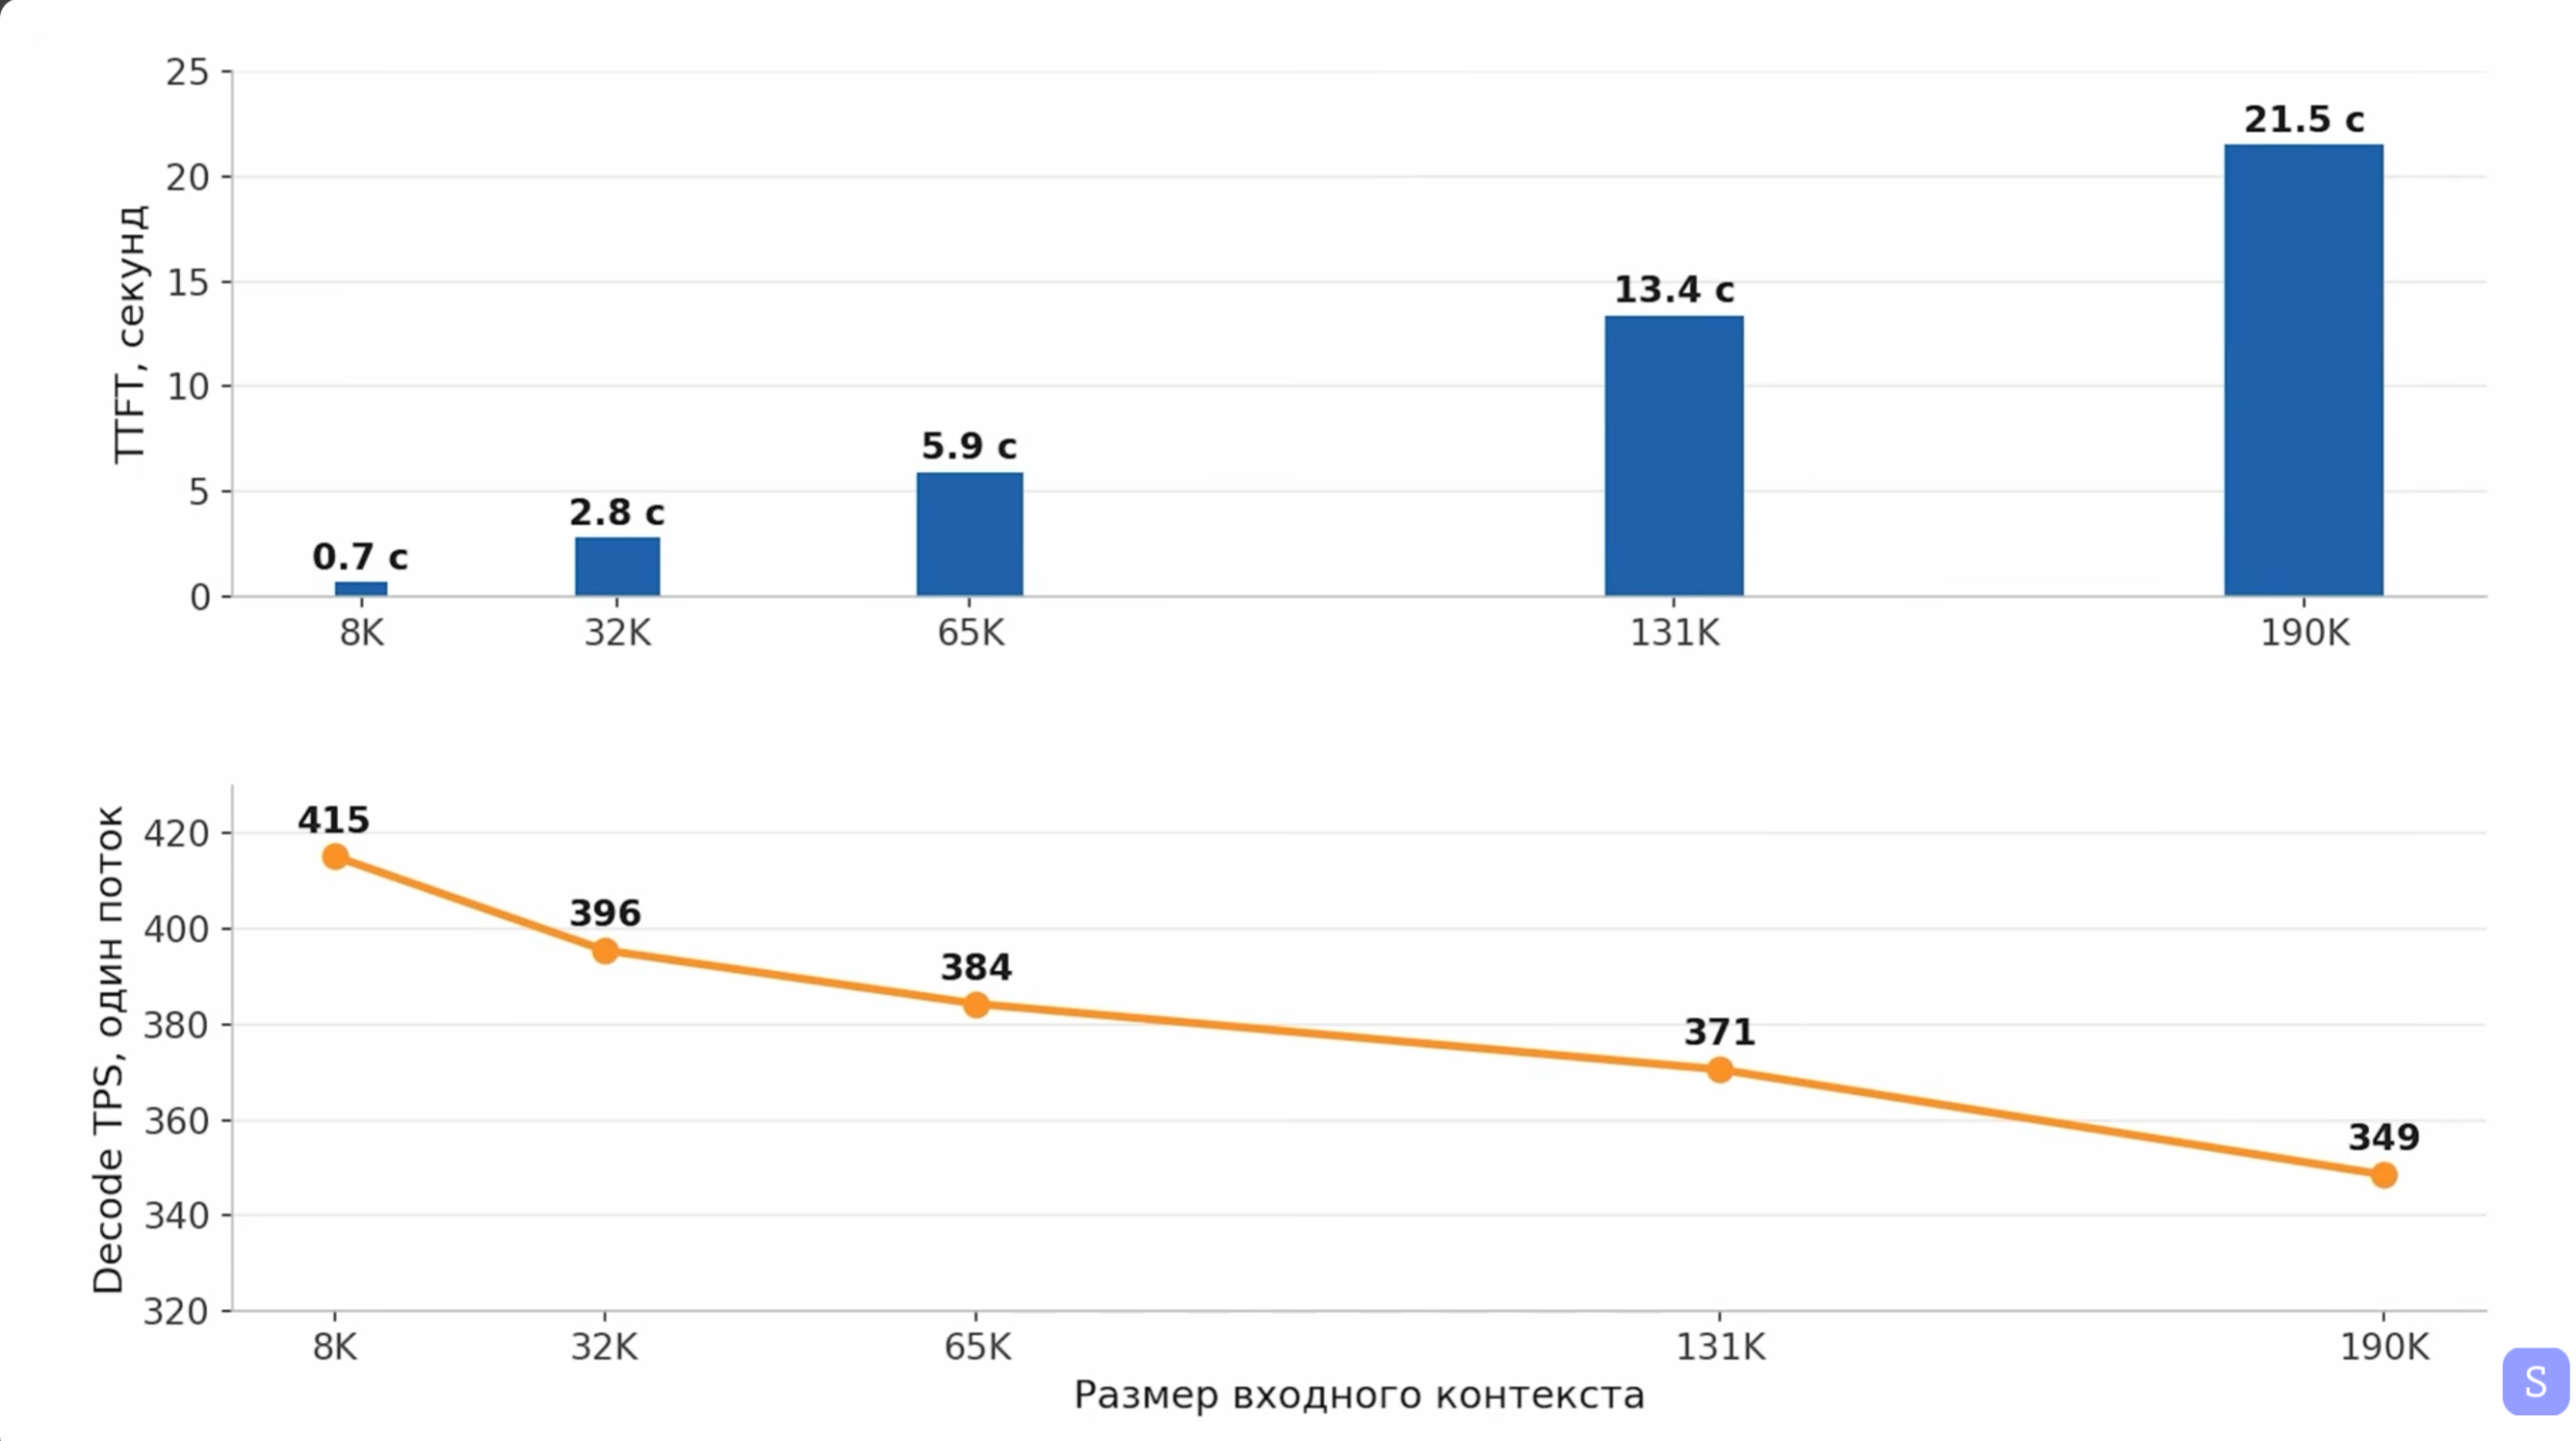

При экстремальном контексте в 190K токенов (практически лимит левого контейнера — 196K) вам придется ждать старта генерации целых 21.5 секунды. Видеокарты в этот момент на пределе своих возможностей переваривают гигантский объем информации.  

Почему скорость падает? Когда модель генерирует каждое следующее слово, ей приходится «оглядываться» на всё то, что было до него. Если до этого было 8 тысяч слов, проверить связи между ними — минутное дело для GPU. Но если сзади висит история на 190 тысяч токенов, видеокартам приходится каждую миллисекунду лопатить колоссальный объем данных в KV-кэше, из-за чего скорость генерации неизбежно снижается.

График подтверждает, что модель способна выдавать отличную скорость (выше 340 токенов/сек) даже на 190K контекста, но только если у сервера есть те самые «бонусные» 100 ГБ памяти под KV-кэш, о которых мы говорили ранее. Без них на отметках 131K и 190K контейнер просто вылетел бы с ошибкой.